In [15]:
import math 
import numpy as np 
import matplotlib.pyplot as plt 
import logging

In [16]:
import tensorflow as tf
import tensorflow_datasets as tfds

In [17]:
logger = tf.get_logger()
logger.setLevel(logging.ERROR)

In [18]:
logger = tf.get_logger()
logger.setLevel(logging.ERROR)

In [19]:
dataset, metadata = tfds.load("mnist", as_supervised=True, with_info=True)
train_dataset,test_dataset = dataset["train"],dataset["test"]

In [12]:
class_names = ["cero","uno","dos","tres","cuatro","cinco","seis","siete", "ocho", "nueve"]

In [14]:
num_train_examples = metadata.splits["train"].num_examples
num_test_examples = metadata.splits["test"].num_examples

In [20]:
def normalize(images,labels):
    images = tf.cast(images,tf.float32)
    images /= 255
    return images, labels

In [21]:
train_dataset = train_dataset.map(normalize)
test_dataset = test_dataset.map(normalize)

In [22]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28,1)), #capa de entrada
    tf.keras.layers.Dense(64, activation=tf.nn.relu), #capa oculta
    tf.keras.layers.Dense(64, activation=tf.nn.relu), #capa oculta
    tf.keras.layers.Dense(10,activation=tf.nn.softmax)
])
    

C:\Users\jedua\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [23]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [24]:
BATCHSIZE = 32
train_dataset = train_dataset.repeat().shuffle(num_train_examples).batch(BATCHSIZE)
test_dataset = test_dataset.batch(BATCHSIZE)

In [26]:
model.fit(
    train_dataset,epochs=5,
    steps_per_epoch=math.ceil(num_train_examples/BATCHSIZE)
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9207 - loss: 0.2712
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9607 - loss: 0.1297
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9730 - loss: 0.0891
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9781 - loss: 0.0697
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9816 - loss: 0.0597


In [29]:
test_loss, test_accuracy = model.evaluate(
    test_dataset, steps=math.ceil(num_test_examples/32)
)

print("Resultado en las pruebas: " , test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9739 - loss: 0.0895
Resultado en las pruebas:  0.9739000201225281


In [32]:
for test_images, test_labels in test_dataset.take(1):
    test_images = test_images.numpy()
    test_labels = test_labels.numpy()
    predictions = model.predict(test_images)

def plot_image(i, predictions_array,true_labels, images):
    predictions_array, true_label,img = predictions_array[i], true_labels[i], images[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])

    plt.imshow(img[...,0], cmap=plt.cm.binary)

    predicted_label = np.argmax(predictions_array)
    if predicted_label == true_label:
        color = "blue"
    else:
        color = "red"

    plt.xlabel("Prediccion: {}".format(class_names[predicted_label]), color=color)

def plot_value_array(i,predictions_array, true_label):
    predictions_array, true_label = predictions_array[i], true_label[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    thisplot = plt.bar(range(10), predictions_array, color= "#888888")
    plt.ylim([0,1])
    predicted_label = np.argmax(predictions_array)


    thisplot[predicted_label].set_color("red")
    thisplot[true_label].set_color("blue")

    
    

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


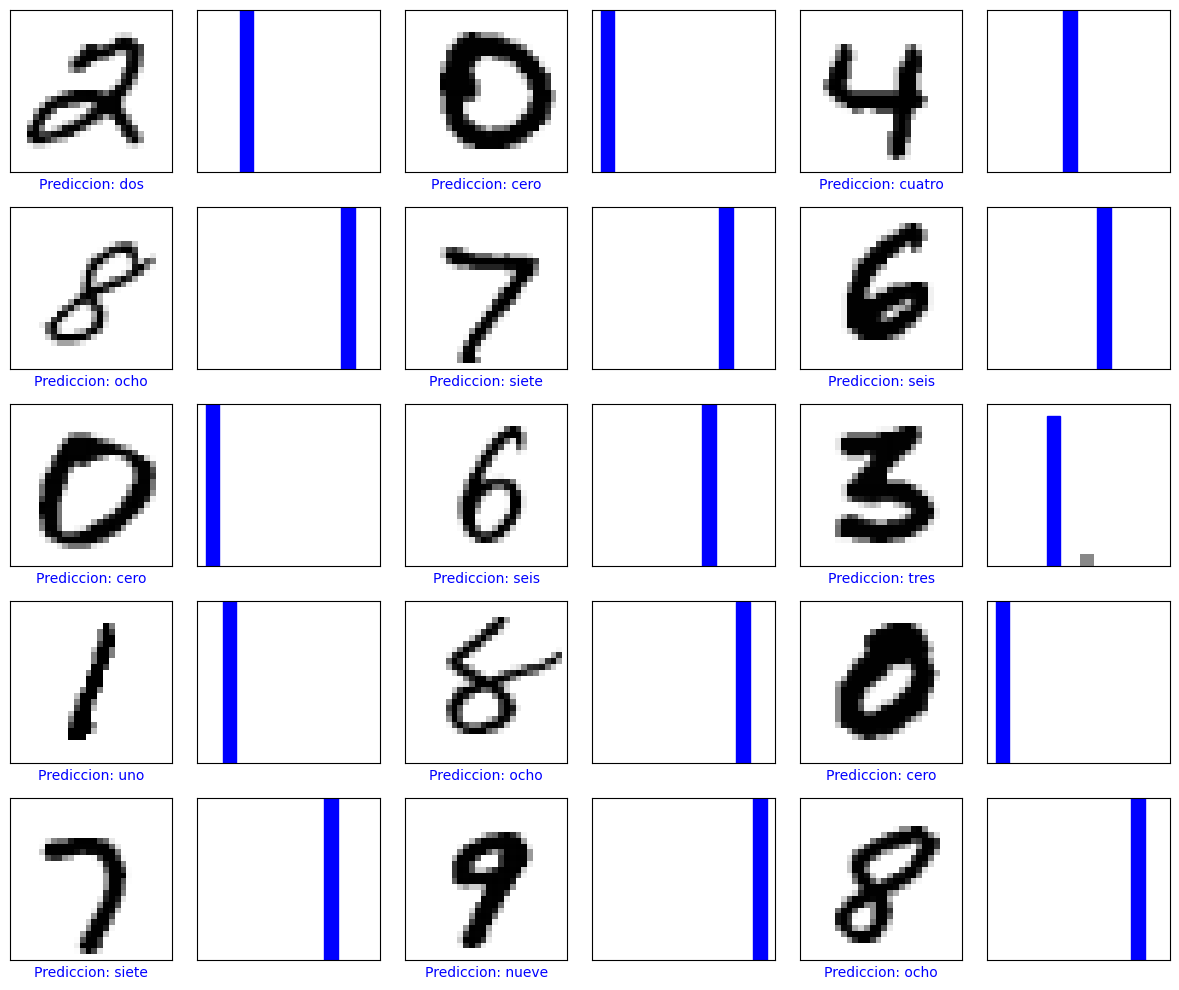

In [33]:
num_rows = 5
num_cols = 3
num_images = num_rows * num_cols

# Cada imagen necesita 2 "slots": uno para el dibujo, otro para la barra
plt.figure(figsize=(2 * 2 * num_cols, 2 * num_rows))

for i in range(num_images):
    # Slot izquierdo: la imagen del dígito
    plt.subplot(num_rows, 2 * num_cols, 2 * i + 1)
    plot_image(i, predictions, test_labels, test_images)
    
    # Slot derecho: la barra de probabilidades por clase
    plt.subplot(num_rows, 2 * num_cols, 2 * i + 2)
    plot_value_array(i, predictions, test_labels)

plt.tight_layout()
plt.show()